In [1]:
from helper_utils import project_embeddings, word_wrap
from pypdf import PdfReader
import os
from openai import OpenAI
from dotenv import load_dotenv


from pypdf import PdfReader
import numpy as np
import umap

load_dotenv()

openai_key = os.getenv("OPENAI_API_KEY")
client = OpenAI(api_key=openai_key)



/Users/quazirazeenjubair/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
reader = PdfReader("docs/microsoft-annual-report.pdf")
pdf_texts = [p.extract_text().strip() for p in reader.pages]

pdf_texts = [text for text in pdf_texts if text]


from langchain.text_splitter import (
    RecursiveCharacterTextSplitter,
    SentenceTransformersTokenTextSplitter,
)

character_splitter = RecursiveCharacterTextSplitter(
    separators=["\n\n", "\n", ". ", " ", ""], chunk_size=1000, chunk_overlap=0
)
character_split_texts = character_splitter.split_text("\n\n".join(pdf_texts))


token_splitter = SentenceTransformersTokenTextSplitter(
    chunk_overlap=0, tokens_per_chunk=256
)

token_split_texts = []
for text in character_split_texts:
    token_split_texts += token_splitter.split_text(text)



/Users/quazirazeenjubair/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [19]:
# now we import chromadb and the SentenceTransformerEmbeddingFunction
import chromadb
from chromadb.utils.embedding_functions import SentenceTransformerEmbeddingFunction


embedding_function = SentenceTransformerEmbeddingFunction()

chroma_client = chromadb.Client()
chroma_collection = chroma_client.get_or_create_collection(
    name="microsoft-collection", embedding_function=embedding_function
)

ids = [str(i) for i in range(len(token_split_texts))]

# Add documents to the collection
chroma_collection.add(ids=ids, documents=token_split_texts)

query = "What was the total revenue of the year?"

results = chroma_collection.query(query_texts=[query], n_results=5)

retrieved_documents = results["documents"][0]

print(retrieved_documents)


['general and administrative $ 7, 575 $ 5, 900 28 % as a percent of revenue 4 % 3 % 1ppt 35', 'segment revenue and operating income were as follows during the periods presented : no sales to an individual customer or country other than the united states accounted for more than 10 % of revenue for fiscal years 2023, 2022, or 2021. revenue, classified by the major geographic areas in which our customers were located, was as follows : ( a ) includes billings to oems and certain multinational organizations because of the nature of these businesses and the impracticability of determining the geographic source of the revenue. ( in millions ) year ended june 30, 2023 2022 2021 revenue productivity and business processes $ 69, 274 $ 63, 364 $ 53, 915 intelligent cloud 87, 907 74, 965 59, 728 more personal computing 54, 734 59, 941 54, 445 total $ 211, 915 $ 198, 270 $ 168, 088 operating income productivity and business processes $ 34, 189 $ 29, 690 $ 24, 351 intelligent cloud 37, 884 33, 203 2

In [4]:
def generate_multi_query(query, model="gpt-3.5-turbo"):

    prompt = """
    You are a knowledgeable financial research assistant. 
    Your users are inquiring about an annual report. 
    For the given question, propose up to five related questions to assist them in finding the information they need. 
    Provide concise, single-topic questions (withouth compounding sentences) that cover various aspects of the topic. 
    Ensure each question is complete and directly related to the original inquiry. 
    List each question on a separate line without numbering.
                """

    messages = [
        {
            "role": "system",
            "content": prompt,
        },
        {"role": "user", "content": query},
    ]

    response = client.chat.completions.create(
        model=model,
        messages=messages,
    )
    content = response.choices[0].message.content
    content = content.split("\n")
    return content

In [5]:
original_query = ("What details can you provide about the factors that led to revenue growth?")

aug_queries = generate_multi_query(original_query)

for query in aug_queries:
    print("\n", query)

    


 - What were the key products or services driving revenue growth?

 - Did geographic regions play a role in the revenue increase?

 - Were there any specific marketing or sales strategies that contributed to the growth in revenue?

 - Did any external factors, such as changes in the market or industry trends, influence revenue growth?

 - How did the pricing strategy impact the revenue growth?


In [22]:
joint_query = [original_query] + aug_queries
results = chroma_collection.query(
    query_texts=joint_query, n_results=5, include=["documents", "embeddings", "distances"]
)

retrieved_documents = results["documents"][0]

In [8]:
print(retrieved_documents)

[]


In [9]:
unique_documents = set()
for documents in retrieved_documents:
    for document in documents:
        unique_documents.add(document)


In [10]:
unique_documents

set()

In [11]:
for i, documents in enumerate(retrieved_documents):
    print(f"Query: {joint_query[i]}")
    print("")
    print("Results:")
    for doc in documents:
        print(word_wrap(doc))
        print("")
    print("-" * 100)

In [20]:
embeddings = chroma_collection.get(include=["embeddings"])["embeddings"]
umap_transform = umap.UMAP(random_state=0, transform_seed=0).fit(embeddings)
projected_dataset_embeddings = project_embeddings(embeddings, umap_transform)

original_query_embedding = embedding_function([original_query])
augmented_query_embeddings = embedding_function([joint_query])







/Users/quazirazeenjubair/Library/Python/3.9/lib/python/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [23]:
project_original_query = project_embeddings(original_query_embedding, umap_transform)
project_augmented_queries = project_embeddings(
    augmented_query_embeddings, umap_transform
)

retrieved_embeddings = results["embeddings"]
result_embeddings = [item for sublist in retrieved_embeddings for item in sublist]

projected_result_embeddings = project_embeddings(result_embeddings, umap_transform)

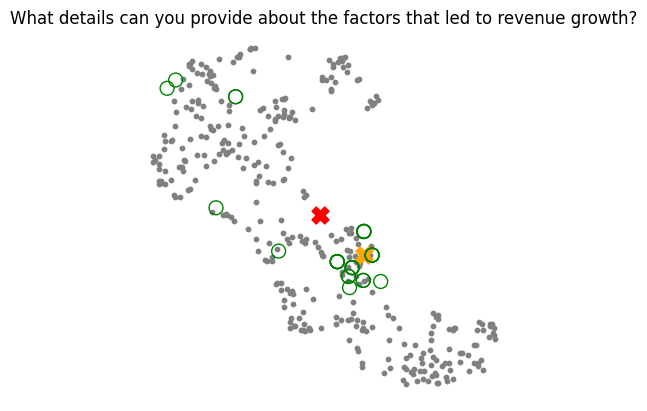

In [24]:

project_original_query = project_embeddings(original_query_embedding, umap_transform)
project_augmented_queries = project_embeddings(
    augmented_query_embeddings, umap_transform
)

retrieved_embeddings = results["embeddings"]
result_embeddings = [item for sublist in retrieved_embeddings for item in sublist]

projected_result_embeddings = project_embeddings(result_embeddings, umap_transform)

import matplotlib.pyplot as plt


# Plot the projected query and retrieved documents in the embedding space
plt.figure()
plt.scatter(
    projected_dataset_embeddings[:, 0],
    projected_dataset_embeddings[:, 1],
    s=10,
    color="gray",
)
plt.scatter(
    project_augmented_queries[:, 0],
    project_augmented_queries[:, 1],
    s=150,
    marker="X",
    color="orange",
)
plt.scatter(
    projected_result_embeddings[:, 0],
    projected_result_embeddings[:, 1],
    s=100,
    facecolors="none",
    edgecolors="g",
)
plt.scatter(
    project_original_query[:, 0],
    project_original_query[:, 1],
    s=150,
    marker="X",
    color="r",
)

plt.gca().set_aspect("equal", "datalim")
plt.title(f"{original_query}")
plt.axis("off")
plt.show()  # display the plot